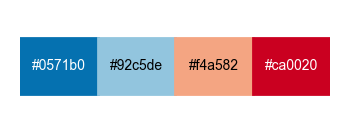

In [19]:
import matplotlib.pyplot as plt

colors = ['#0571b0', '#92c5de', '#f4a582', '#ca0020']
labels = ['#0571b0', '#92c5de', '#f4a582', '#ca0020']

fig, ax = plt.subplots(figsize=(2, 0.6), dpi=200)

for i, (c, lab) in enumerate(zip(colors, labels)):
    # 画色块
    ax.add_patch(plt.Rectangle((i, 0.2), 1, 0.6, color=c))
    
    # 写标签（在色块中间）
    ax.text(i + 0.5, 0.5, lab,
            ha='center', va='center',
            fontsize=5,
            color='white' if i in [0, 3] else 'black')  # 深色用白字更清晰

ax.set_xlim(0, len(colors))
ax.set_ylim(0, 1)
ax.axis('off')

plt.show()

In [20]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from common import *

# input and output

In [21]:
IBDMDB_file = '../../Data/IBDMDB/Data1_metadata_from_ibdmdb.xlsx'
HGM_file = '../../Data/IBDMDB/taxonomic_profiles.tsv'

In [22]:
HGM_data = pd.read_csv(HGM_file,sep='\t')
HGM_data.head()

,#SampleID,CSM5FZ4M,CSM5MCUO,CSM5MCVL,CSM5MCVN,CSM5MCW6,CSM5MCWC,CSM5MCWE,CSM5MCWG,CSM5MCWQ,...,CSM5MCVJ_P,CSM5MCWI_P,MSM5LLHA_P,HSM5MD59_P,HSM5MD8N_P,CSM6J2H9_P,HSM5MD4A_P,CSM5MCUW_P,ESM5MEBA_P,HSM5FZC2_P
0,k__Archaea,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000093,0.0,0.0
1,k__Archaea|p__Euryarchaeota,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000093,0.0,0.0
2,k__Archaea|p__Euryarchaeota|c__Methanobacteria,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000093,0.0,0.0
3,k__Archaea|p__Euryarchaeota|c__Methanobacteria...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000093,0.0,0.0
4,k__Archaea|p__Euryarchaeota|c__Methanobacteria...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000093,0.0,0.0


In [23]:
IBDMDB_data = pd.read_excel(IBDMDB_file,sheet_name = 'Person_Sample')
IBDMDB_data.head(3)

,Project,External ID,Participant ID,site_sub_coll,data_type,week_num,date_of_receipt,interval_days,visit_num,IntervalName,...,Age at diagnosis,Education Level,Occupation,consent_age,diagnosis,General wellbeing,Abdominal pain,baseline_montreal_location,race,sex
0,G79889,CSM5FZ3N_P,C3001,C3001C1,metagenomics,0,2014-03-14,0,4,Stool Collection #1,...,28.0,Bachelor's degree,Paid,43,CD,Slightly below par,Mild,L3,White,Female
1,G79894,CSM5FZ3R_P,C3001,C3001C2,metagenomics,2,2014-03-28,14,5,Stool Collection #2,...,28.0,Bachelor's degree,Paid,43,CD,Very Well,Mild,L3,White,Female
2,G79903,CSM5YRY7_P,C3001,C3001C3,metagenomics,4,2014-04-15,18,6,Stool Collection #3,...,28.0,Bachelor's degree,Paid,43,CD,Poor,Mild,L3,White,Female


In [24]:
def get_sampleID_by_peopleID(peopleID,IBDMDB_data):
    tmp_df = IBDMDB_data[IBDMDB_data['Participant ID']==peopleID]
    return tmp_df['External ID'].to_list()

In [25]:
def deal_sampleinfo_level(HGM_data, level='f__'):
    HGM_data_levellist = HGM_data['#SampleID'].to_list()
    # 返回索引和level
    HGM_data_levellist = [(i, x.split('|')[4].replace(level, '')) 
                         for i, x in enumerate(HGM_data_levellist) 
                         if len(x.split('|')) == 5]
    return HGM_data_levellist

# 调用函数
HGM_data_levellist = deal_sampleinfo_level(HGM_data, level='f__')

def get_sampleID_abundance(sampleID,HGM_data,HGM_data_levellist):
    sampleID_abundance = HGM_data[sampleID].to_list()
    abundance_dict = {}
    for index, level in HGM_data_levellist:   # ✅ 不要用 .items()
        if level not in abundance_dict:
            abundance_dict[level] = sampleID_abundance[index]
        else:
            abundance_dict[level] += sampleID_abundance[index]
    abundance_dict = {k:v for k,v in abundance_dict.items() if v>0}
    
    return abundance_dict

sampleID = 'CSM5FZ4M'
get_sampleID_abundance(sampleID,HGM_data,HGM_data_levellist)

{'Propionibacteriaceae': 0.0001691,
 'Coriobacteriaceae': 0.000145,
 'Bacteroidaceae': 0.687465,
 'Porphyromonadaceae': 0.0796653,
 'Rikenellaceae': 0.062968,
 'Clostridiaceae': 0.0009454,
 'Clostridiales_noname': 0.0001955,
 'Eubacteriaceae': 0.0043921,
 'Lachnospiraceae': 0.010232,
 'Oscillospiraceae': 0.0041547,
 'Ruminococcaceae': 0.116388,
 'Erysipelotrichaceae': 0.0003619,
 'Acidaminococcaceae': 0.0311922,
 'Veillonellaceae': 0.0001278,
 'Desulfovibrionaceae': 0.000523,
 'Enterobacteriaceae': 0.0010136,
 'Potyviridae': 6.19e-05}

# 量化稳定性

In [26]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# === Step 1. 数据处理 ===
def prepare_family_abundance(data_dict, normalize=True, sort_family=True):
    """
    统一 family-level 相对丰度表，并计算 Bray–Curtis 距离矩阵
    返回：
        dist_matrix - Bray-Curtis 距离矩阵
    """
    df = pd.DataFrame.from_dict(data_dict, orient='index').fillna(0)
    if normalize:
        df = df.div(df.sum(axis=1), axis=0)
    if sort_family:
        df = df[sorted(df.columns)]
        
    dist = pdist(df.values, metric='braycurtis')
    dist_matrix = pd.DataFrame(squareform(dist), index=df.index, columns=df.index)
    return dist_matrix

# === 热图 ===
def plot_bray_curtis_heatmap(dist_matrix, title=None):
    samples = dist_matrix.index

    plt.figure(figsize=(2, 2), dpi=300)
    plt.rcParams.update({'font.size': 6})
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['pdf.fonttype'] = 42

    im = plt.imshow(dist_matrix, cmap='RdBu_r', interpolation='nearest', vmin=0, vmax=1)

    # === colorbar ===
    cbar = plt.colorbar(im, shrink=0.8)
    cbar.set_label('Bray-Curtis distance', fontsize=6, fontweight='bold')
    cbar.ax.tick_params(labelsize=4, width=1, length=2, direction='out')
    for spine in cbar.ax.spines.values():
        spine.set_linewidth(1)  # 设置为和主图一致的 0.5
    plt.xticks(range(len(samples)), samples, rotation=90, fontsize=4)
    plt.yticks(range(len(samples)), samples, fontsize=4)
        
    ax = plt.gca()
    # === 通用边框 ===
    ax.spines['top'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.spines['right'].set_linewidth(1)

    # === 坐标轴 ===
    plt.tick_params(axis='both', direction='out', width=1, which='both', length=4, pad=2)

    if title:
        plt.title(title, fontsize=6, fontweight='bold', pad=3)

    plt.subplots_adjust(left=0.15, right=0.98, bottom=0.15, top=0.98)
    plt.show()

# === 相邻时间点折线图 ===
def plot_temporal_stability(dist_matrix, figure_path, title=None):
    samples = list(dist_matrix.index)
    distances = [dist_matrix.loc[samples[i], samples[i+1]] for i in range(len(samples)-1)]

    plt.figure(figsize=(2.2, 0.8), dpi=400)
    plt.rcParams.update({'font.size': 6})
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['pdf.fonttype'] = 42

    plt.plot(range(1, len(samples)), distances, '-o', color='#5B8FA8', lw=1, ms=2)
    # ===== 参考线（你原来的阈值）=====
    plt.axhline(0.5, linestyle='--', linewidth=0.5, color='black')
    
    plt.xticks(range(1, len(samples)), samples[1:], rotation=90, fontsize=4)
    plt.yticks(fontsize=4)
    plt.ylabel("Adjacent Bray-Curtis\ndistance", fontsize=6, fontweight='bold')
    plt.ylim(0, 1)

    # === 通用边框 ===
    ax = plt.gca()
    ax.spines['top'].set_linewidth(0)
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.spines['right'].set_linewidth(0)

    # === 坐标轴 ===
    plt.tick_params(axis='both', direction='out', width=1, which='both', length=4, pad=2)

    if title:
        plt.title(title, fontsize=6, fontweight='bold', pad=3)
        
    # plt.subplots_adjust(left=0.15, right=0.98, bottom=0.15, top=0.98)
    plt.savefig(figure_path, dpi=400, bbox_inches='tight')
    plt.show()

## 5-ASA

======== E5004 ========


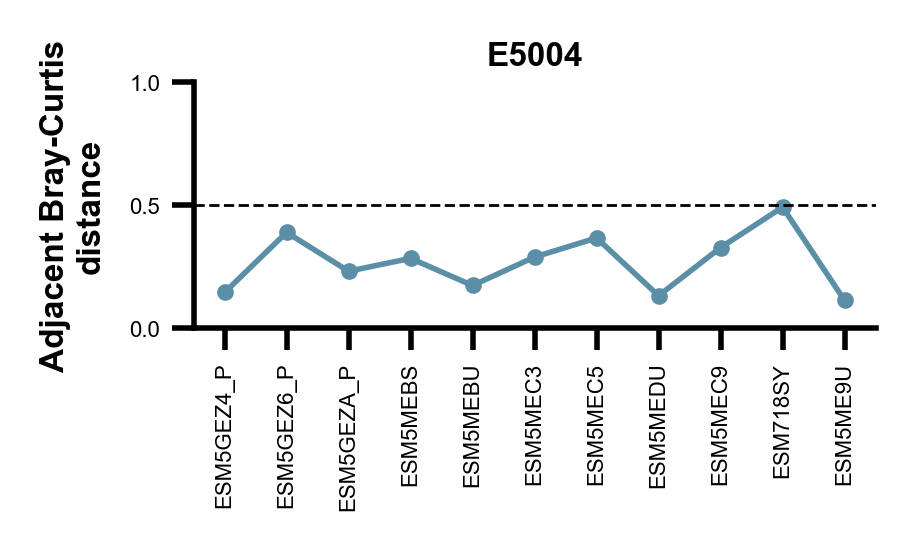

======== H4007 ========


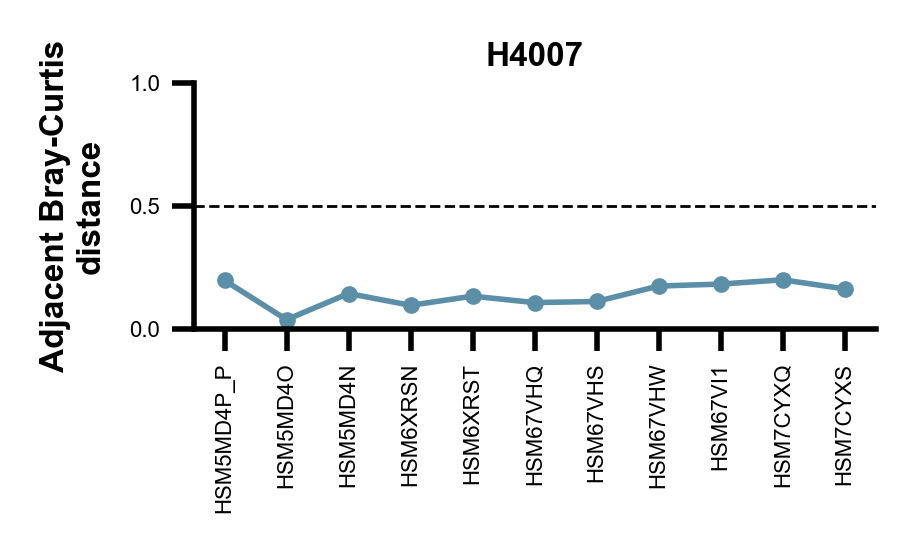

======== H4014 ========


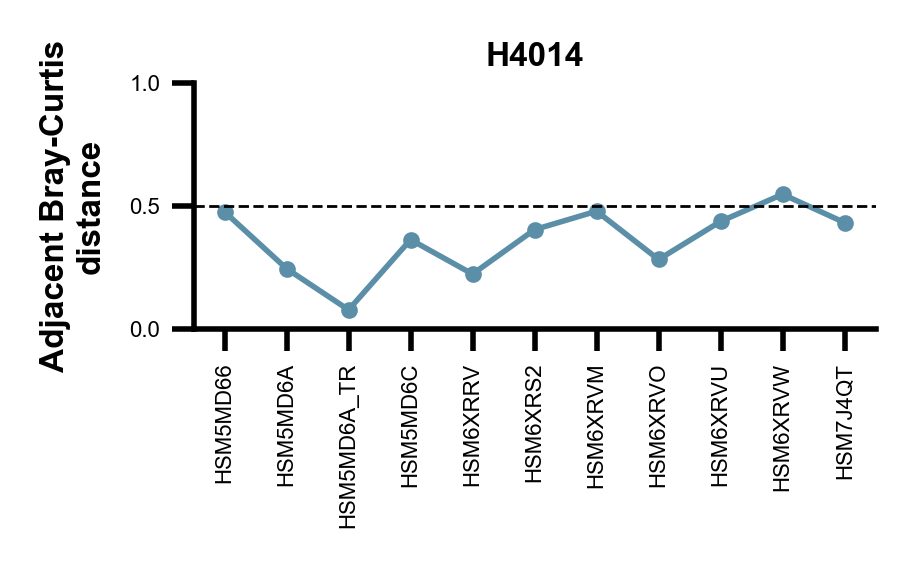

======== H4015 ========


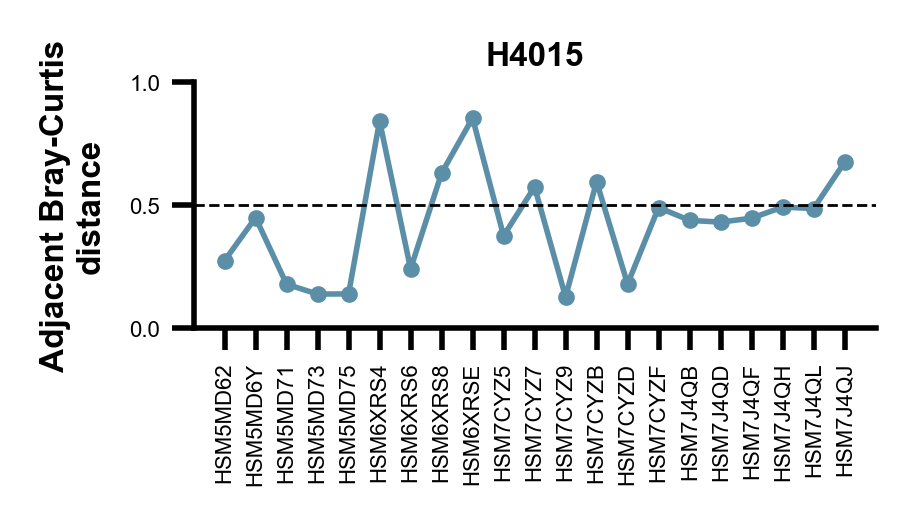

======== H4019 ========


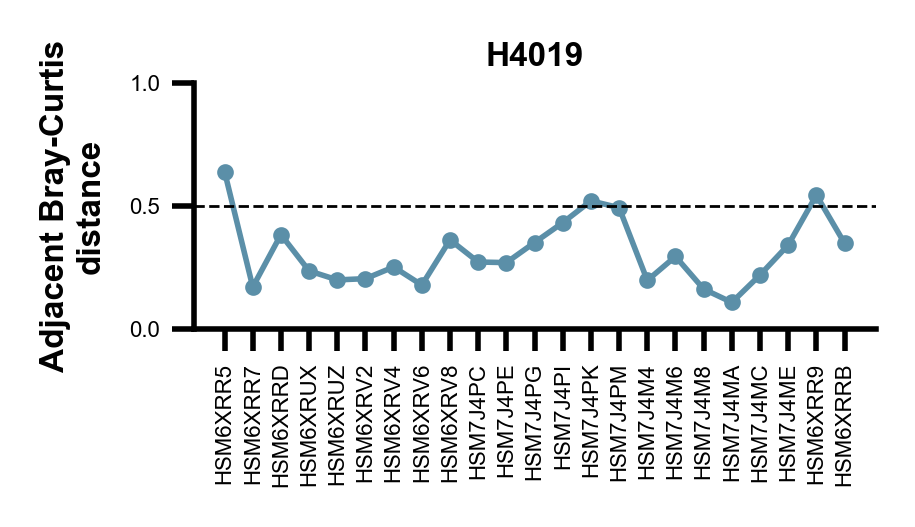

======== H4035 ========


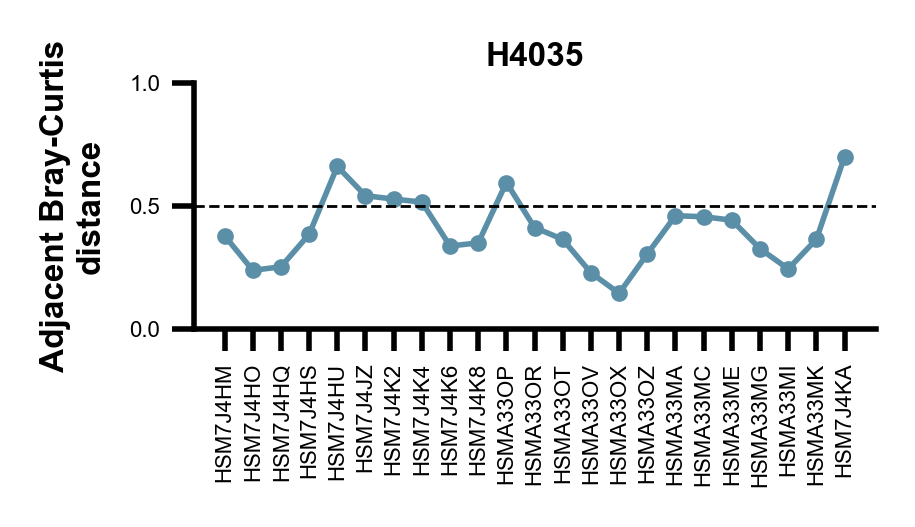

======== H4040 ========


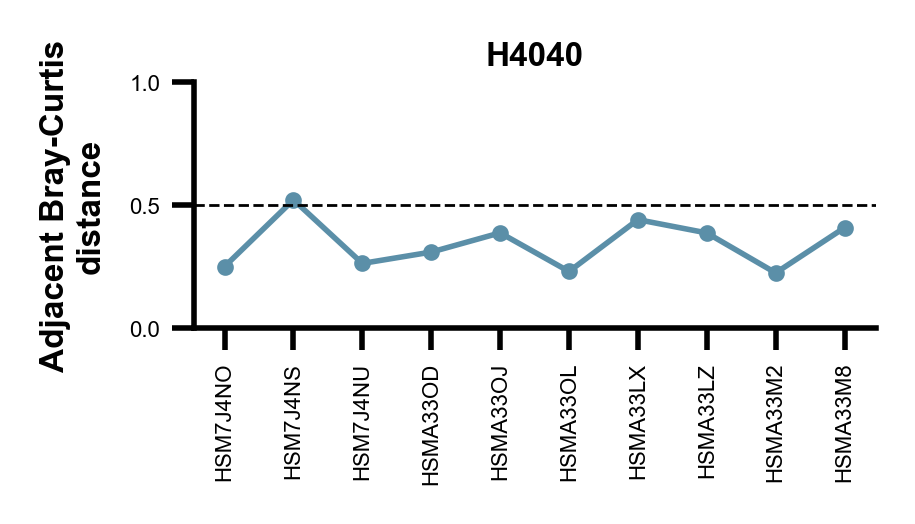

======== H4042 ========


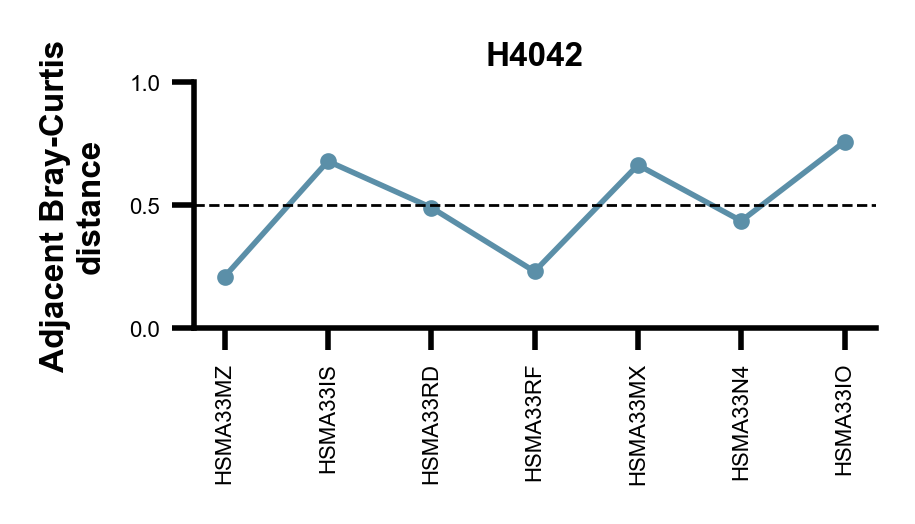

======== H4043 ========


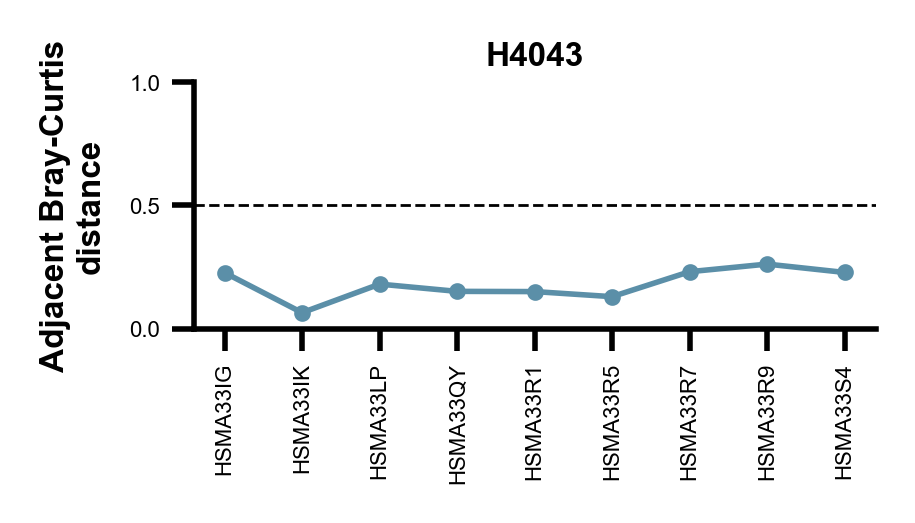

======== M2014 ========


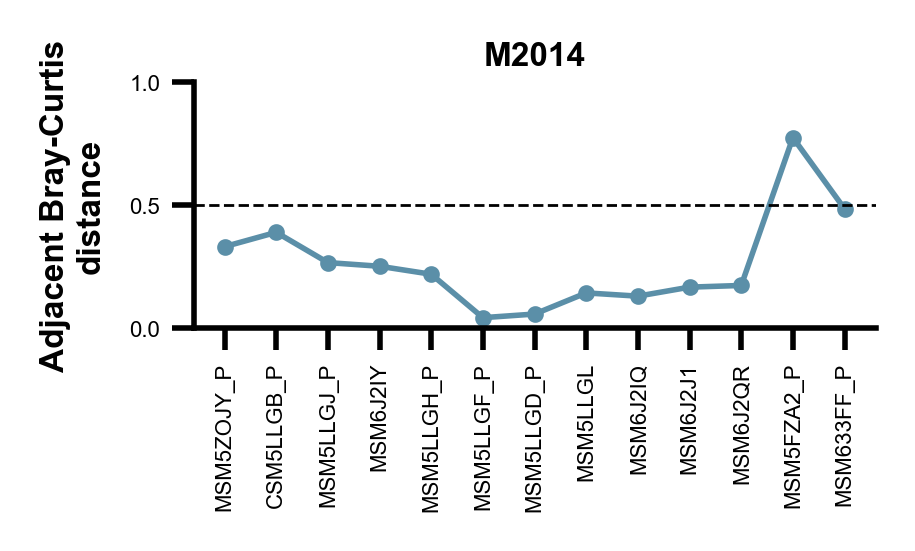

======== M2028 ========


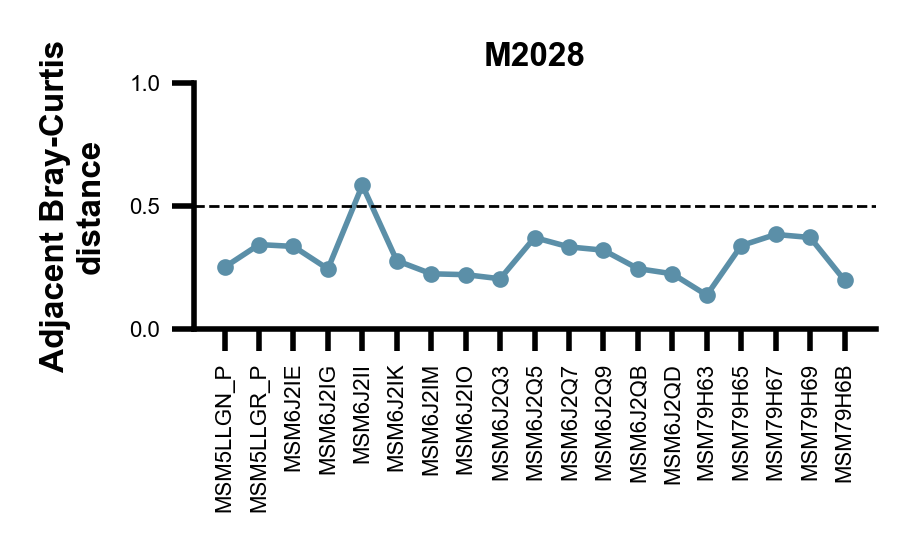

======== P6028 ========


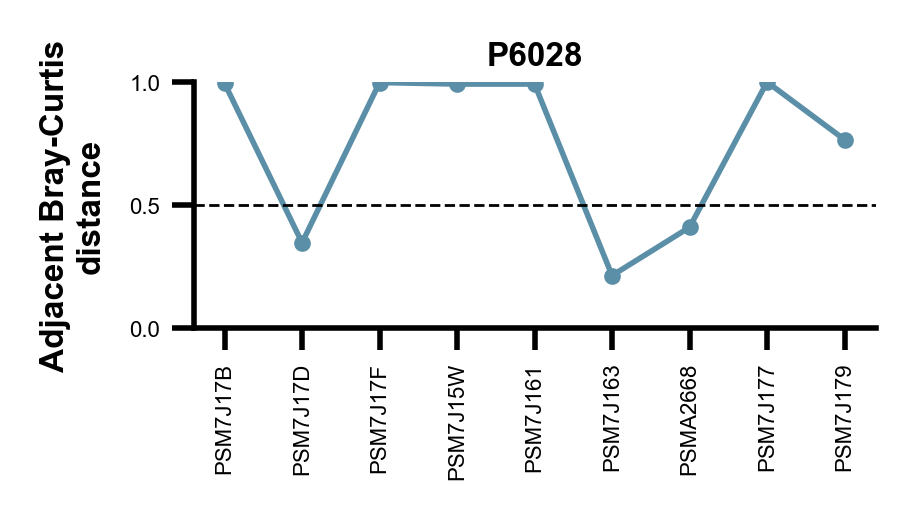

======== P6005 ========


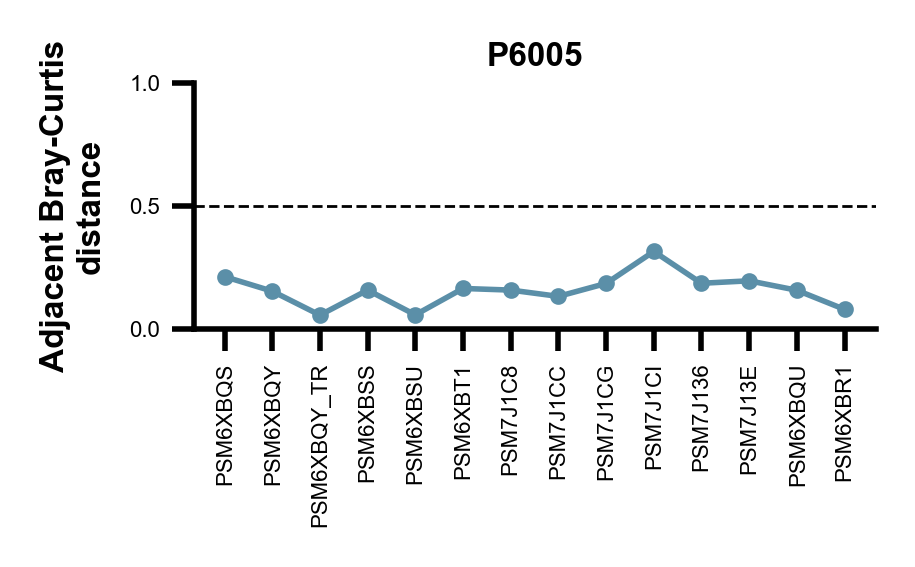

======== C3010 ========


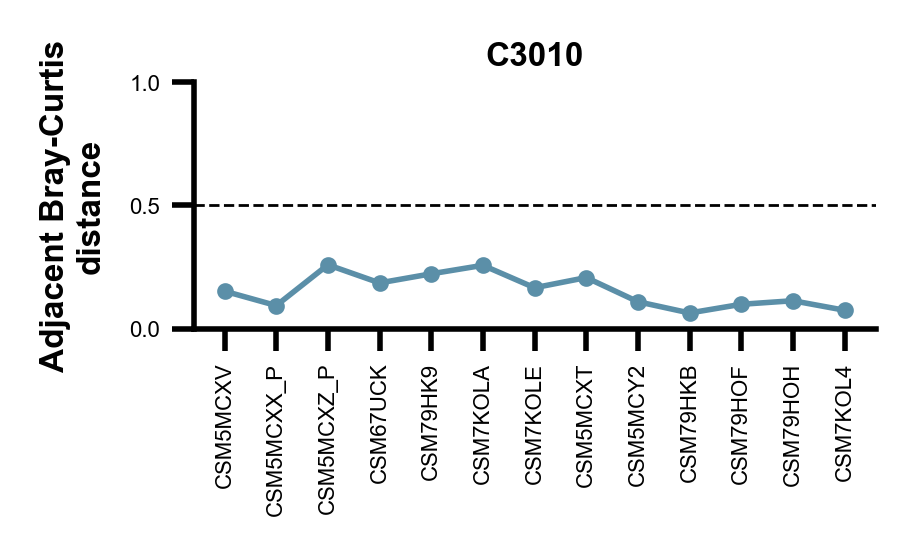

======== C3030 ========


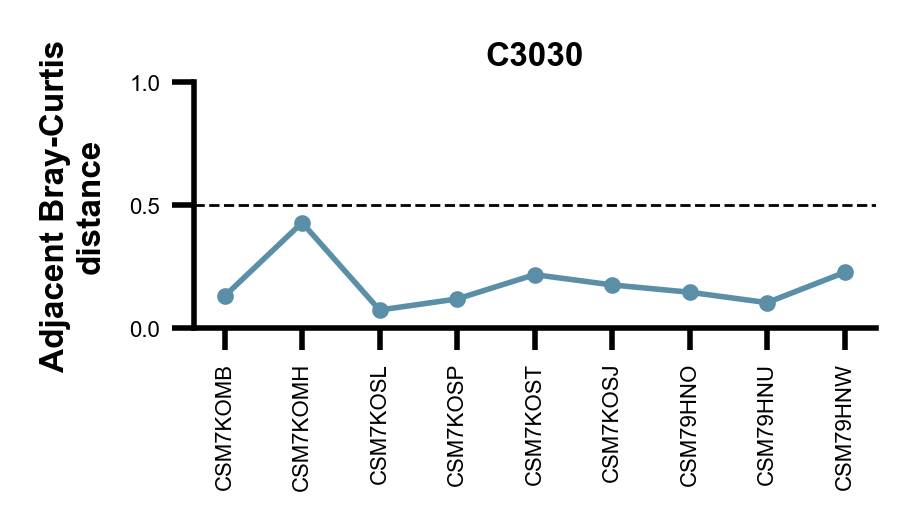

======== C3035 ========


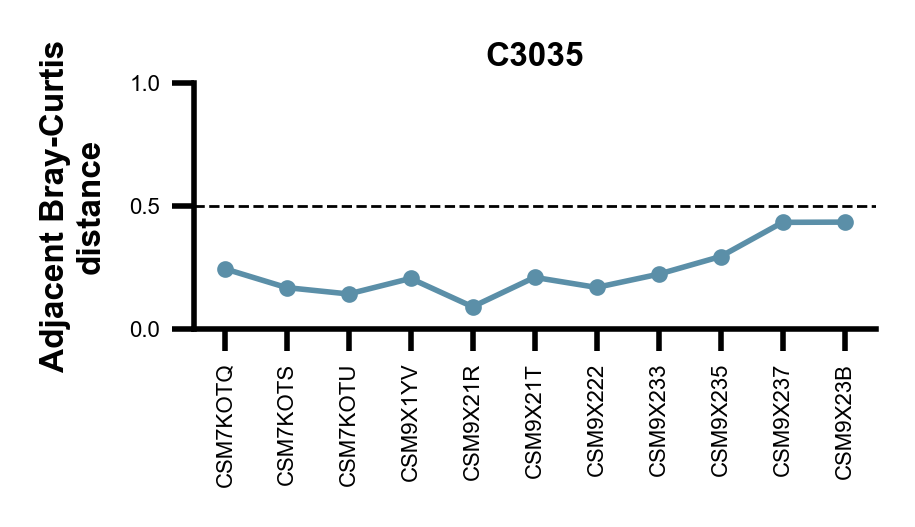

======== C3037 ========


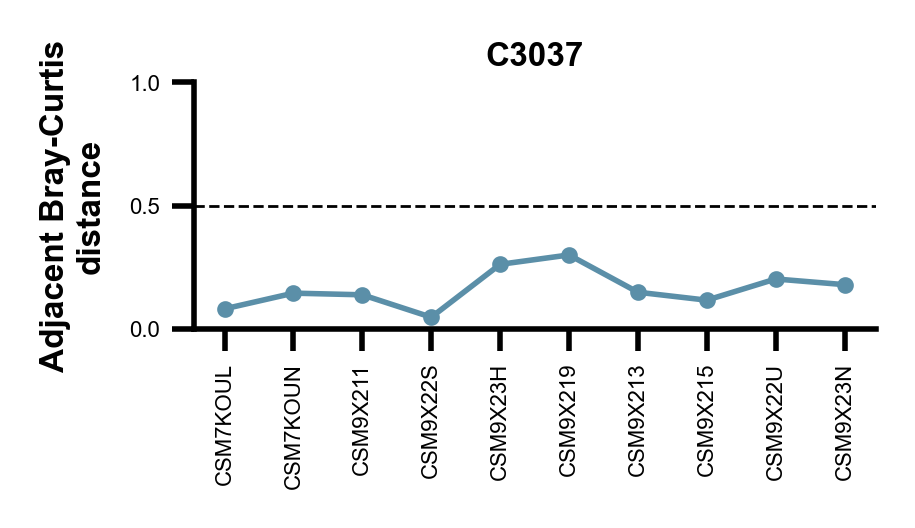

======== P6010 ========


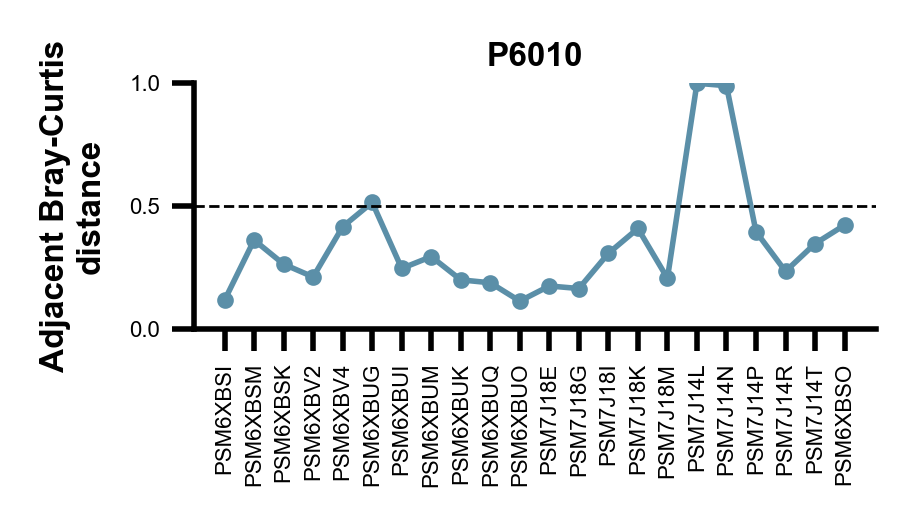

In [27]:
peopleID_list = set(IBDMDB_data['Participant ID'].to_list())

peopleID_list = ['E5004','H4007','H4014','H4015','H4019','H4035','H4040','H4042','H4043',
                 'M2014','M2028','P6028','P6005','C3010','C3030','C3035','C3037','P6010',
                 ]
for peopleID in peopleID_list:
    print('========',peopleID,'========')
    sampleID_list = get_sampleID_by_peopleID(peopleID,IBDMDB_data)
    all_data = {}
    key_counter = Counter()
    for sampleID in sampleID_list:
        abund_dict = get_sampleID_abundance(sampleID, HGM_data, HGM_data_levellist)
        all_data[sampleID] = abund_dict
    dist_matrix = prepare_family_abundance(all_data)
    # plot_bray_curtis_heatmap(dist_matrix, title=peopleID)
    figure_path = '../../Figure/Figure-S4-' + peopleID + '.pdf'
    plot_temporal_stability(dist_matrix, figure_path, title=peopleID)

## 6-MP

======== C3002 ========


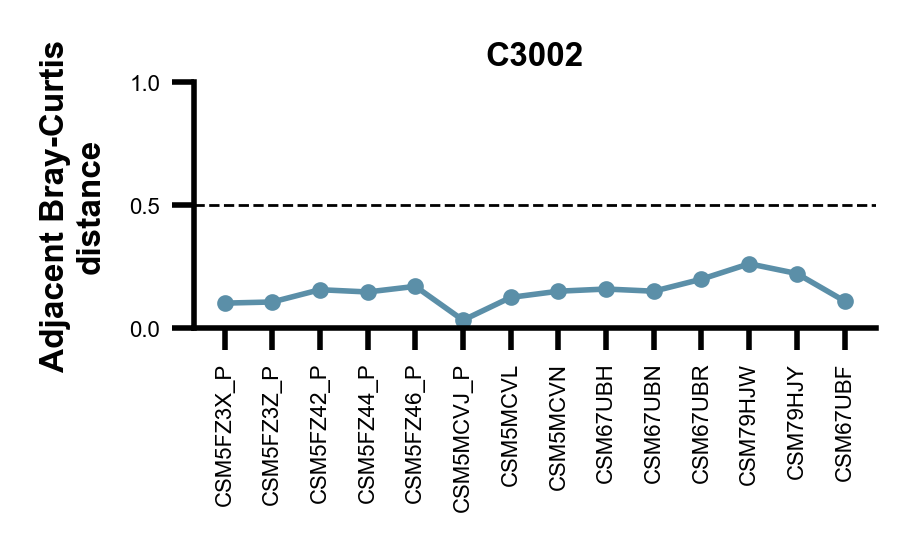

======== C3010 ========


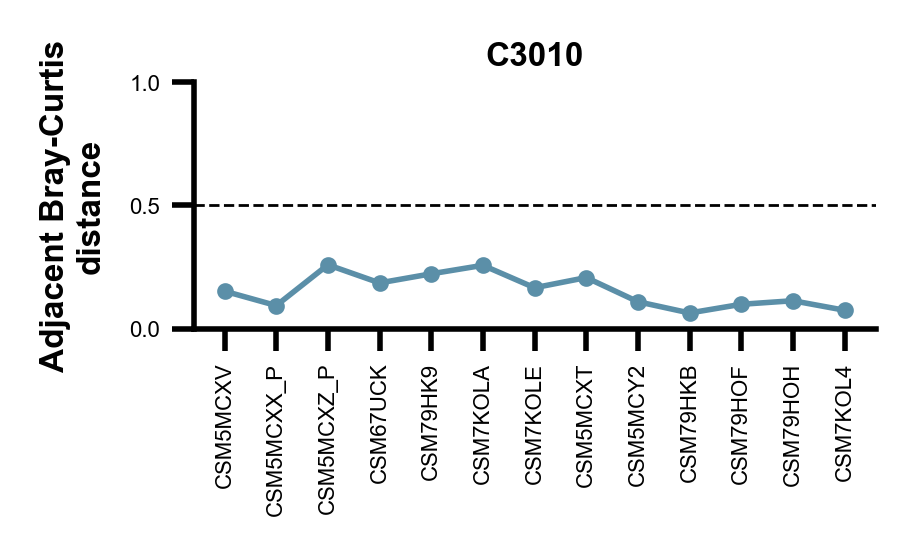

======== C3011 ========


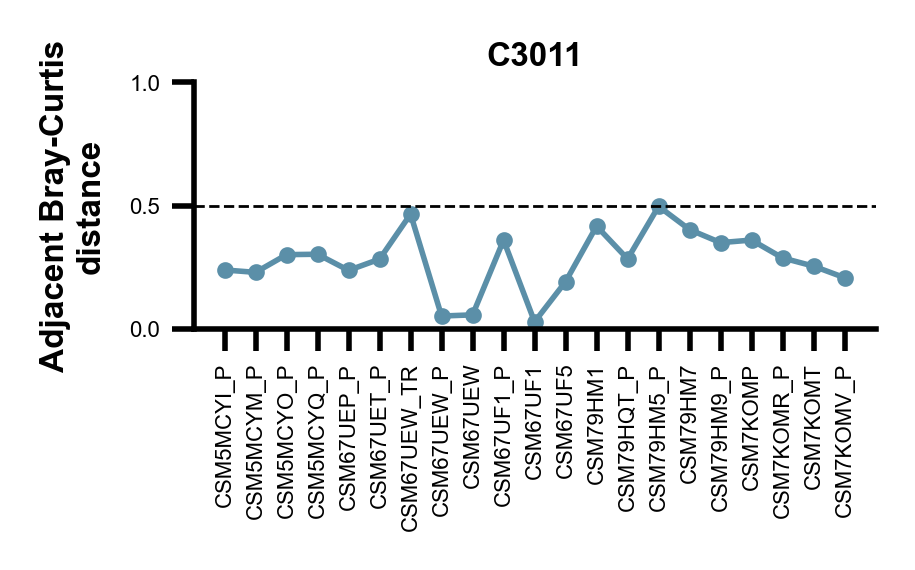

======== C3013 ========


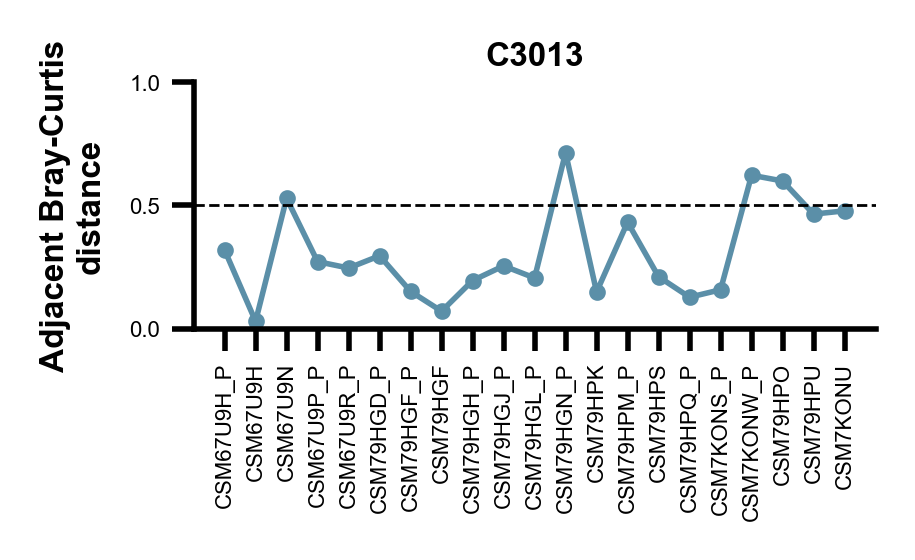

======== C3021 ========


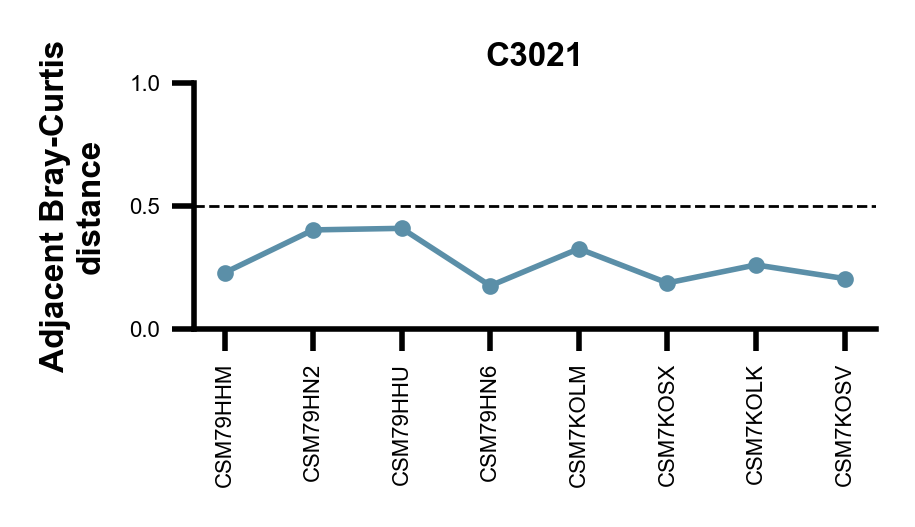

======== H4007 ========


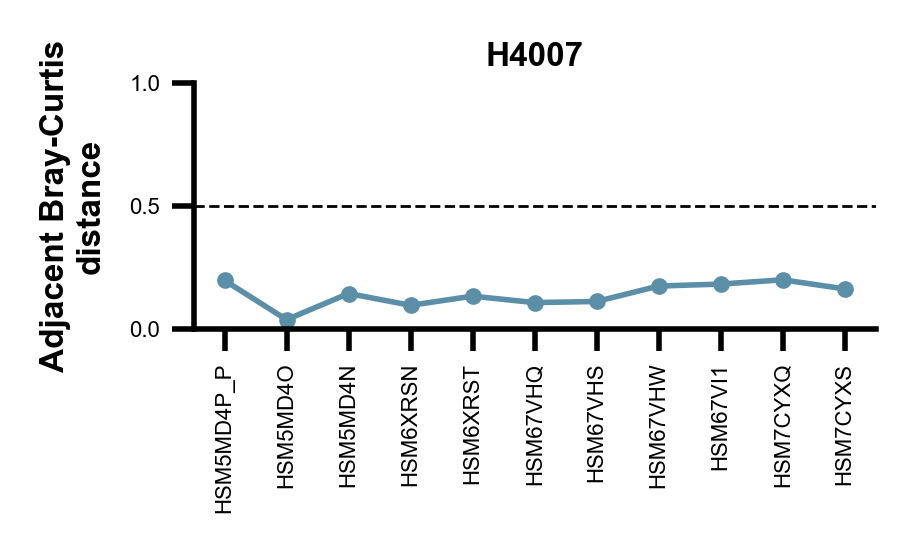

======== H4014 ========


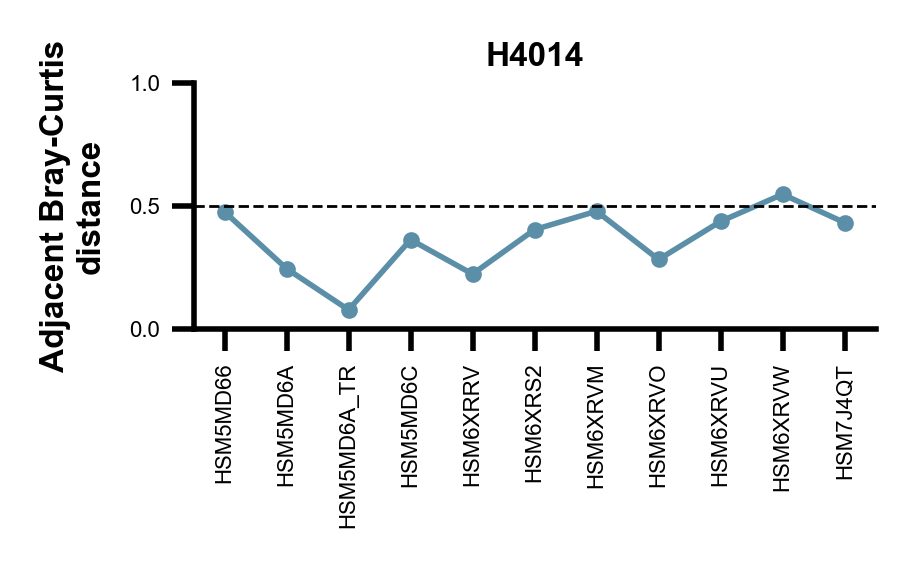

======== H4019 ========


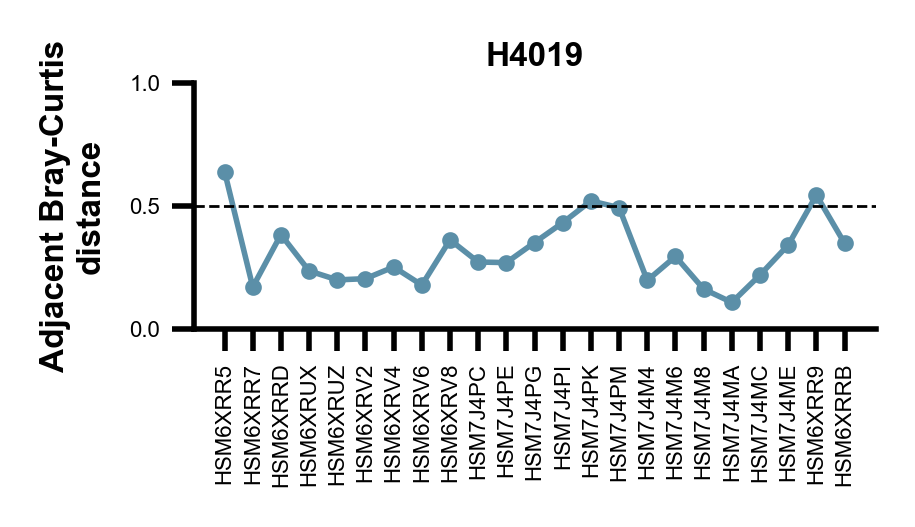

======== H4030 ========


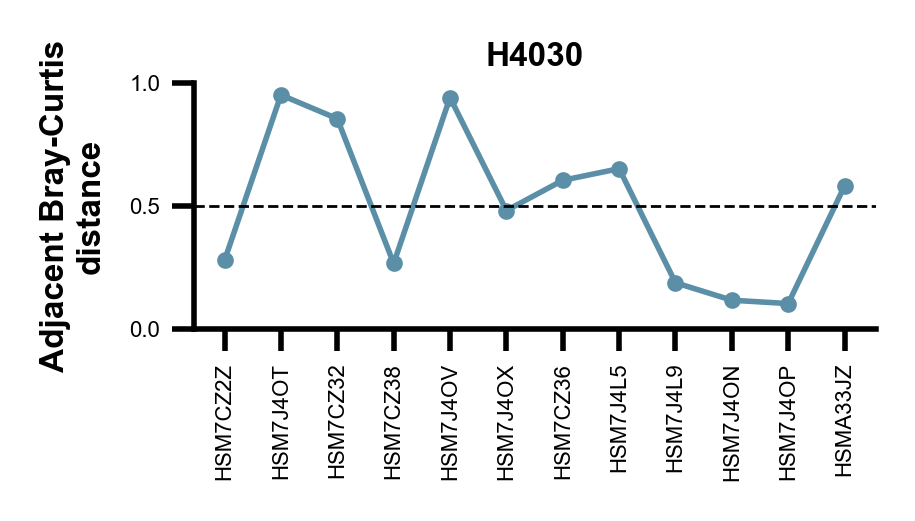

======== H4043 ========


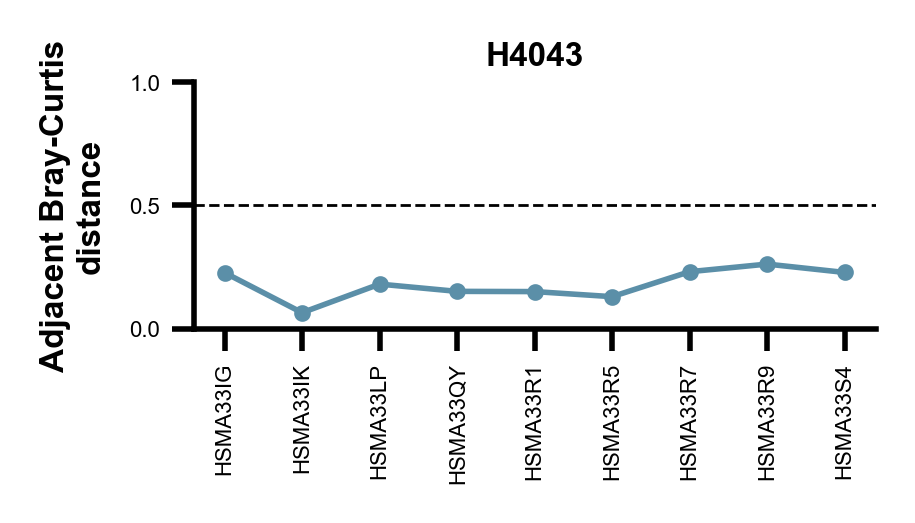

======== M2034 ========


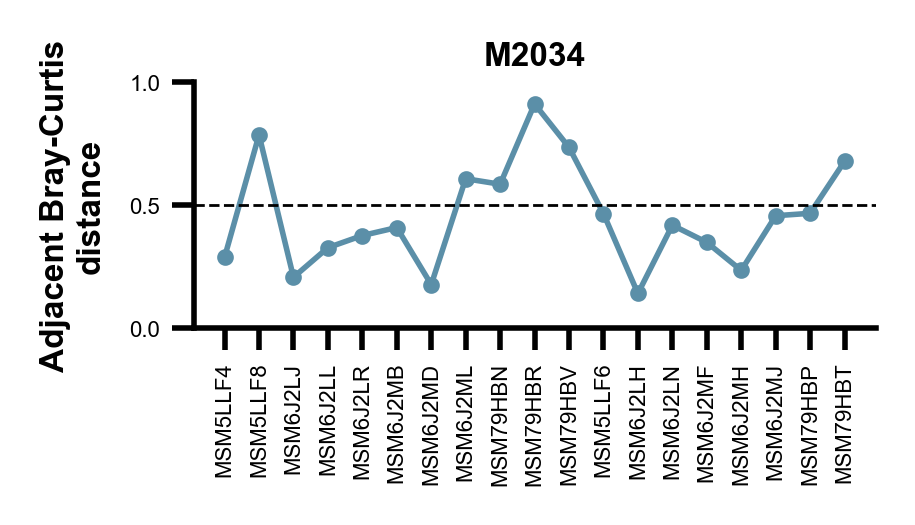

======== C3023 ========


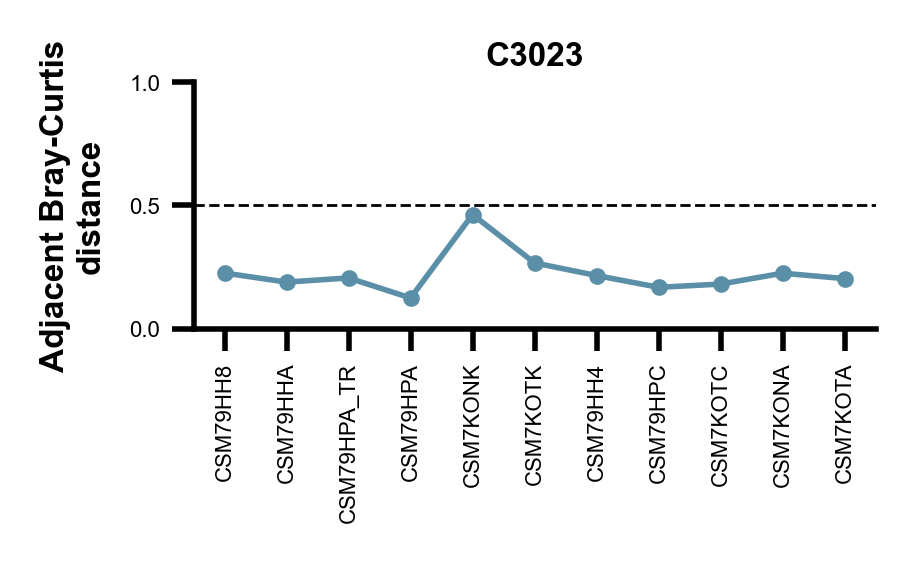

======== C3030 ========


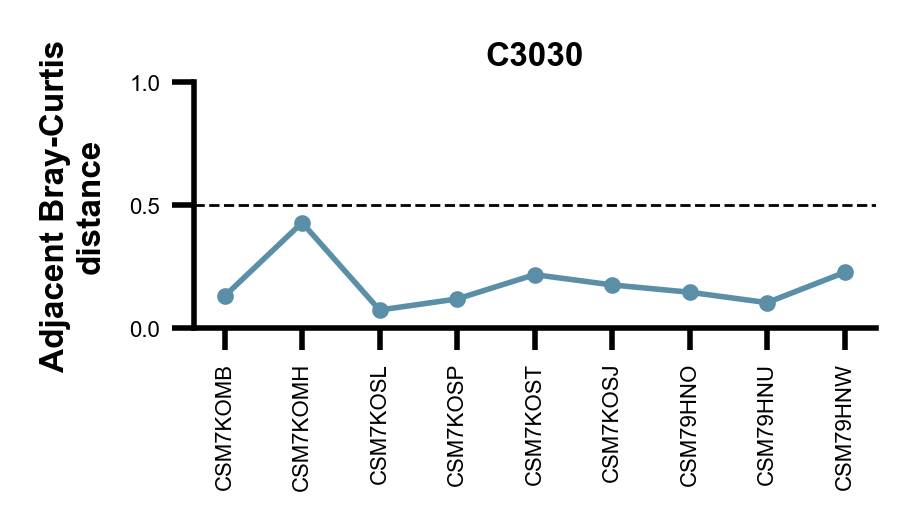

======== C3035 ========


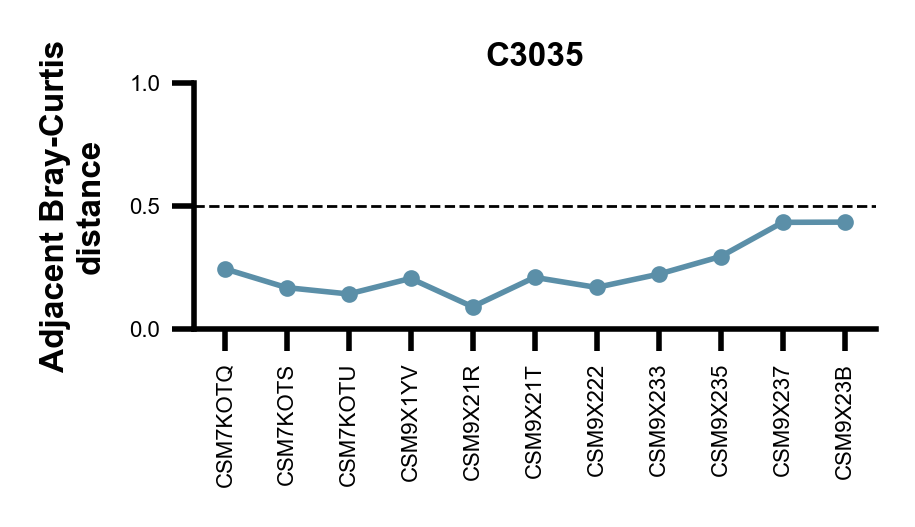

In [28]:
peopleID_list = set(IBDMDB_data['Participant ID'].to_list())

peopleID_list = ['C3002','C3010','C3011','C3013','C3021','H4007','H4014','H4019',
                 'H4030','H4043','M2034',
                 'C3023','C3030','C3035',
                 ]
for peopleID in peopleID_list:
    print('========',peopleID,'========')
    sampleID_list = get_sampleID_by_peopleID(peopleID,IBDMDB_data)
    all_data = {}
    key_counter = Counter()
    for sampleID in sampleID_list:
        abund_dict = get_sampleID_abundance(sampleID, HGM_data, HGM_data_levellist)
        all_data[sampleID] = abund_dict
    dist_matrix = prepare_family_abundance(all_data)
    # plot_bray_curtis_heatmap(dist_matrix, title=peopleID)
    figure_path = '../../Figure/Figure-S5-' + peopleID + '.pdf'
    plot_temporal_stability(dist_matrix, figure_path, title=peopleID)